First, I will import all of the libraries and methods that I plan to use

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from ml_from_scratch.supervised.single_neuron import SingleNeuron, identity


I will now load the data and split into training and testing data for the model

In [3]:

# Loading the diabetes dataset

data = load_diabetes()
X = data.data        
y = data.target      

In [ ]:

# Splitting into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 353
Testing samples:  89


Now that we've split the data into training and testing data, we are ready to train our model. We will pass the identity function into the SingleNeuron model. Note that as described in the readme, this is very similar to the perceptron if we were to pass the sign function in instead. That however would not work with the gradient descent method as it is not a differentiable function.

In [12]:

# First we will train the model

model = SingleNeuron(activation_function=identity)
model.train(X_train, y_train, alpha=0.01, epochs=1000)

In [13]:

# Calculating mean squared error on the training set, test set, and the combination of the two

train_mse = np.mean((model.predict(X_train) - y_train) ** 2)
test_mse  = np.mean((model.predict(X_test)  - y_test)  ** 2)
total_mse = np.mean((model.predict(X) - y )**2)
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE:  {test_mse:.2f}")
print(f"Total MSE: {total_mse:.2f}" )

Train MSE: 2901.38
Test MSE:  2898.46
Total MSE: 2900.79


These numbers seem pretty big but there are some pretty important signs that this is actually a good thing. Notice that the training and testing error is very similar. We can do a couple things to check if these high numbers are ok. First we will plot the MSE versus time in order to check that it decreased overtime.

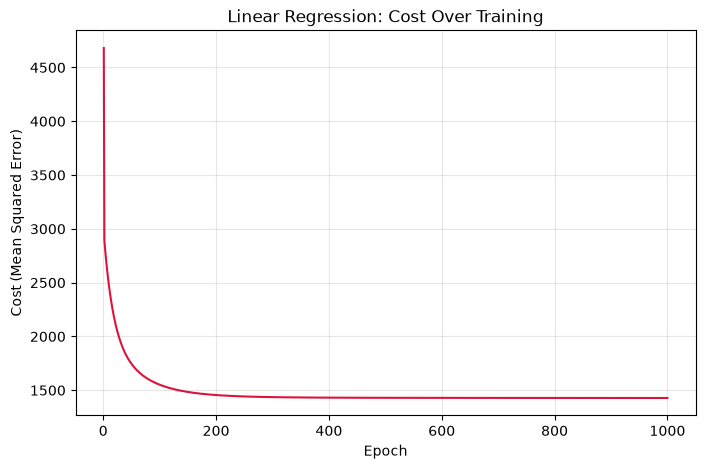

In [14]:

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(model.errors_) + 1), model.errors_, color='crimson')
plt.xlabel('Epoch')
plt.ylabel('Cost (Mean Squared Error)')
plt.title('Linear Regression: Cost Over Training')
plt.grid(True, alpha=0.3)
plt.show()

This is a very promising graph, as the MSE rapidly decreased after around 200 trials. The high MSE is then likely a product of the final values simply being large. This shows how effective gradient descent is at reaching an optimal outcome. An additional thing we can check is a predicted versus actual plot to ensure that the values are consistently pretty close within the range they are supposed to be

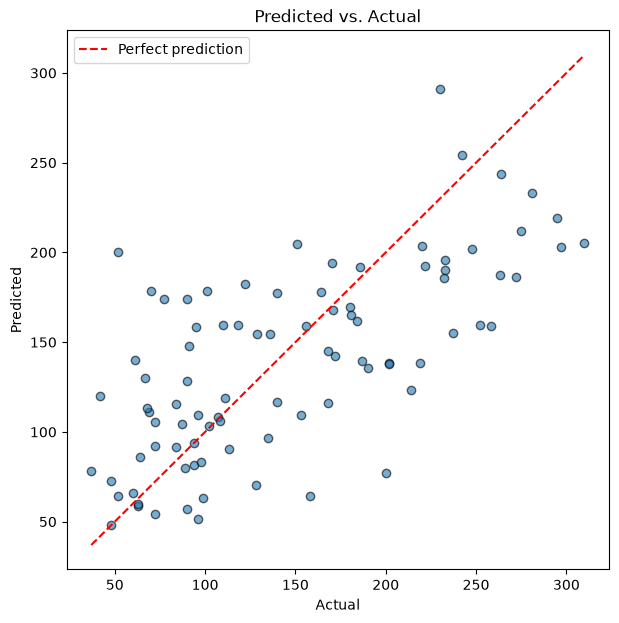

In [15]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, model.predict(X_test), alpha=0.6, edgecolor='k')
# diagonal line = perfect predictions
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs. Actual')
plt.legend()
plt.show()

As shown above, while the model did not predict perfectly, there is a strong correlation between predicted and actual showing that the model did what it was supposed to do.